# Manual Verification of T-seeded ODE Model Computation

This notebook implements the operations executed by `solve_ode_system` computation step-by-step for single parameter values.

**Purpose**: Verify manually single combinations of parameters and understand the ODE-based computation flow.

**Key Difference from Lump Model**: 
- Lump model uses analytical steady-state solution
- T-seeded model uses ODE integration to track dynamic tritium inventory evolution through fuel cycle systems

## Block 1: Define All Input Parameters

Set all input parameters needed for the T-seeded ODE model computation.

In [232]:
import numpy as np
import sys
sys.path.insert(0, '/Users/meschini/Documents/dd_startup')

# ============================================================================
# PHYSICAL CONSTANTS
# ============================================================================

# Tritium decay constant (s^-1)
lambda_T = np.log(2) / (12.32 * 365.25 * 24 * 3600)  # Half-life = 12.32 years

# Tritium atomic mass (kg)
tritium_mass = 3.016 * 1.66054e-27  # 3 AMU in kg
joule_to_GWh = 1/3.6e12  # Conversion factor from Joules to GWh
# Fusion reaction energies (J)
E_DDp = 4.03e6 * 1.60218e-19    # DD→³He+n: 4.03 MeV
E_DDn = 3.46e6 * 1.60218e-19    # DD→T+p: 3.46 MeV (note: different from lump model)
E_DT = 17.6e6 * 1.60218e-19     # DT→⁴He+n: 17.6 MeV

print("Physical Constants Defined:")
print(f"  λ_T (tritium decay constant) = {lambda_T:.6e} s⁻¹")
print(f"  Tritium mass = {tritium_mass:.6e} kg")
print(f"  E_DDp = {E_DDp:.6e} J")
print(f"  E_DDn = {E_DDn:.6e} J")
print(f"  E_DT = {E_DT:.6e} J")
print()

Physical Constants Defined:
  λ_T (tritium decay constant) = 1.782834e-09 s⁻¹
  Tritium mass = 5.008189e-27 kg
  E_DDp = 6.456785e-13 J
  E_DDn = 5.543543e-13 J
  E_DT = 2.819837e-12 J



In [233]:
# ============================================================================
# PLASMA PARAMETERS
# ============================================================================

V_plasma = 150.0                # Plasma volume (m³)
T_i = 14.0                      # Ion temperature (keV)
n_tot = 1.7e20                  # Total particle density (m⁻³)
tau_p_T = 1.0                   # Tritium confinement time (s)

print("Plasma Parameters:")
print(f"  V_plasma = {V_plasma} m³")
print(f"  T_i = {T_i} keV")
print(f"  n_tot = {n_tot:.2e} m⁻³")
print(f"  τ_p_T = {tau_p_T} s")
print()

# ============================================================================
# CALCULATE REACTION RATE COEFFICIENTS (⟨σv⟩) using Bosch-Hale formulas
# ============================================================================
from ddstartup.physics.reactionrates_functions import (
    sigmav_DT_BoschHale,
    sigmav_DD_BoschHale
)

sigmav_DT = sigmav_DT_BoschHale(T_i)
sigmav_DD_tot, sigmav_DD_n, sigmav_DD_p = sigmav_DD_BoschHale(T_i)

print("Reaction Rate Coefficients (calculated at T_i = 69 keV):")
print(f"  ⟨σv⟩_DD_tot = {sigmav_DD_tot:.6e} m³/s")
print(f"  ⟨σv⟩_DD_p (DD→T+p) = {sigmav_DD_p:.6e} m³/s")
print(f"  ⟨σv⟩_DD_n (DD→³He+n) = {sigmav_DD_n:.6e} m³/s")
print(f"  ⟨σv⟩_DT = {sigmav_DT:.6e} m³/s")
print()

Plasma Parameters:
  V_plasma = 150.0 m³
  T_i = 14.0 keV
  n_tot = 1.70e+20 m⁻³
  τ_p_T = 1.0 s

Reaction Rate Coefficients (calculated at T_i = 69 keV):
  ⟨σv⟩_DD_tot = 2.490998e-24 m³/s
  ⟨σv⟩_DD_p (DD→T+p) = 1.282584e-24 m³/s
  ⟨σv⟩_DD_n (DD→³He+n) = 1.208414e-24 m³/s
  ⟨σv⟩_DT = 2.405442e-22 m³/s



In [234]:
# ============================================================================
# POWER AND BREEDING PARAMETERS
# ============================================================================

P_aux = 10e6                    # Auxiliary heating power (W) = 50 MW
P_aux_DT_eq = 10e6              # Auxiliary power for D-T equivalent (W) = 50 MW
TBR_DT = 1.05                   # D-T tritium breeding ratio
TBR_DDn = 0.5                   # DD neutron tritium breeding ratio

print("Power and Breeding Parameters:")
print(f"  P_aux = {P_aux/1e6} MW")
print(f"  P_aux_DT_eq = {P_aux_DT_eq/1e6} MW")
print(f"  TBR_DT = {TBR_DT}")
print(f"  TBR_DDn = {TBR_DDn}")
print()

Power and Breeding Parameters:
  P_aux = 10.0 MW
  P_aux_DT_eq = 10.0 MW
  TBR_DT = 1.05
  TBR_DDn = 0.5



In [235]:
# ============================================================================
# FUEL CYCLE PARAMETERS
# ============================================================================

tau_ifc = 6*3600.0                # In-fuel-cycle processing time (s) = 1 hour
tau_ofc = 12*3600.0               # Out-of-fuel-cycle processing time (s) = 1 day
N_st_min = 0.001 / tritium_mass # Minimum stored tritium for injection (atoms) = 1 mg

print("Fuel Cycle Parameters:")
print(f"  τ_ifc (in-fuel-cycle time) = {tau_ifc} s = {tau_ifc/3600:.2f} hours")
print(f"  τ_ofc (out-of-fuel-cycle time) = {tau_ofc} s = {tau_ofc/86400:.2f} days")
print(f"  N_st_min (minimum stored tritium) = {N_st_min:.2e} atoms = 0.001 kg")
print()

Fuel Cycle Parameters:
  τ_ifc (in-fuel-cycle time) = 21600.0 s = 6.00 hours
  τ_ofc (out-of-fuel-cycle time) = 43200.0 s = 0.50 days
  N_st_min (minimum stored tritium) = 2.00e+23 atoms = 0.001 kg



In [236]:
# ============================================================================
# ECONOMIC AND OPERATIONAL PARAMETERS
# ============================================================================

eta_th = 0.4                    # Thermal efficiency (40%)
capacity_factor = 0.8           # Plant capacity factor (80%)
cost_of_electricity_MWh = 250  # Electricity cost ($/MWh)
cost_of_electricity = cost_of_electricity_MWh / 3.6e9  # Convert $/MWh to $/J

print("Economic and Operational Parameters:")
print(f"  η_th = {eta_th} (thermal efficiency)")
print(f"  Capacity factor = {capacity_factor}")
print(f"  Cost of electricity = {cost_of_electricity:.2e} $/J (or {cost_of_electricity_MWh:.2f} $/MWh)")
print()

Economic and Operational Parameters:
  η_th = 0.4 (thermal efficiency)
  Capacity factor = 0.8
  Cost of electricity = 6.94e-08 $/J (or 250.00 $/MWh)



In [237]:
# ============================================================================
# SIMULATION PARAMETERS
# ============================================================================

total_time = 10 * 365.25 * 24 * 3600  # Maximum simulation time (10 years in seconds)
vector_length = 500                   # Number of time points for output arrays

print("Simulation Parameters:")
print(f"  total_time = {total_time:.2e} s = {total_time/(365.25*24*3600):.1f} years")
print(f"  vector_length = {vector_length} points")
print()

Simulation Parameters:
  total_time = 3.16e+08 s = 10.0 years
  vector_length = 500 points



In [238]:
# ============================================================================
# CALCULATE MAXIMUM INJECTION RATE
# ============================================================================

# Maximum injection rate is determined by equilibrium between:
# - Tritium loss from plasma (n_T/tau_p_T * V_plasma)
# - Tritium consumption by DT reactions (n_D * n_T * sigmav_DT * V_plasma)
# - Tritium production by DD reactions (0.5 * n_D^2 * sigmav_DD_p * V_plasma)
# At DT equilibrium: n_T = n_D = n_tot/2

injection_rate_max = (
    n_tot/2 / tau_p_T * V_plasma +                      # Tritium loss from plasma
    0.25 * n_tot**2 * sigmav_DT * V_plasma -            # Tritium consumption by DT
    0.25 / 2 * n_tot**2 * sigmav_DD_p * V_plasma        # Tritium production by DD
)

print("Maximum Injection Rate:")
print(f"  injection_rate_max = {injection_rate_max:.2e} atoms/s")
print(f"  This is the injection rate needed to maintain DT equilibrium (50-50)")
print()

Maximum Injection Rate:
  injection_rate_max = 1.30e+22 atoms/s
  This is the injection rate needed to maintain DT equilibrium (50-50)



In [239]:
# ============================================================================
# SUMMARY OF ALL VARIABLES DEFINED IN BLOCK 1
# ============================================================================

print("="*80)
print("ALL VARIABLES DEFINED IN BLOCK 1:")
print("="*80)
print("\nPhysical Constants:")
print(f"  lambda_T = {lambda_T:.6e} s⁻¹")
print(f"  tritium_mass = {tritium_mass:.6e} kg")
print(f"  E_DDp = {E_DDp:.6e} J")
print(f"  E_DDn = {E_DDn:.6e} J")
print(f"  E_DT = {E_DT:.6e} J")

print("\nPlasma Parameters:")
print(f"  V_plasma = {V_plasma} m³")
print(f"  T_i = {T_i} keV")
print(f"  n_tot = {n_tot:.2e} m⁻³")
print(f"  tau_p_T = {tau_p_T} s")

print("\nReaction Rates:")
print(f"  sigmav_DD_tot = {sigmav_DD_tot:.6e} m³/s")
print(f"  sigmav_DD_p = {sigmav_DD_p:.6e} m³/s")
print(f"  sigmav_DD_n = {sigmav_DD_n:.6e} m³/s")
print(f"  sigmav_DT = {sigmav_DT:.6e} m³/s")

print("\nPower and Breeding:")
print(f"  P_aux = {P_aux:.2e} W = {P_aux/1e6} MW")
print(f"  P_aux_DT_eq = {P_aux_DT_eq:.2e} W = {P_aux_DT_eq/1e6} MW")
print(f"  TBR_DT = {TBR_DT}")
print(f"  TBR_DDn = {TBR_DDn}")

print("\nFuel Cycle:")
print(f"  tau_ifc = {tau_ifc} s = {tau_ifc/3600:.2f} hours")
print(f"  tau_ofc = {tau_ofc} s = {tau_ofc/86400:.2f} days")
print(f"  N_st_min = {N_st_min:.2e} atoms")
print(f"  injection_rate_max = {injection_rate_max:.2e} atoms/s")

print("\nEconomic/Operational:")
print(f"  eta_th = {eta_th}")
print(f"  capacity_factor = {capacity_factor}")
print(f"  cost_of_electricity = {cost_of_electricity:.2e} $/J")

print("\nSimulation:")
print(f"  total_time = {total_time:.2e} s = {total_time/(365.25*24*3600):.1f} years")
print(f"  vector_length = {vector_length}")
print("="*80)

ALL VARIABLES DEFINED IN BLOCK 1:

Physical Constants:
  lambda_T = 1.782834e-09 s⁻¹
  tritium_mass = 5.008189e-27 kg
  E_DDp = 6.456785e-13 J
  E_DDn = 5.543543e-13 J
  E_DT = 2.819837e-12 J

Plasma Parameters:
  V_plasma = 150.0 m³
  T_i = 14.0 keV
  n_tot = 1.70e+20 m⁻³
  tau_p_T = 1.0 s

Reaction Rates:
  sigmav_DD_tot = 2.490998e-24 m³/s
  sigmav_DD_p = 1.282584e-24 m³/s
  sigmav_DD_n = 1.208414e-24 m³/s
  sigmav_DT = 2.405442e-22 m³/s

Power and Breeding:
  P_aux = 1.00e+07 W = 10.0 MW
  P_aux_DT_eq = 1.00e+07 W = 10.0 MW
  TBR_DT = 1.05
  TBR_DDn = 0.5

Fuel Cycle:
  tau_ifc = 21600.0 s = 6.00 hours
  tau_ofc = 43200.0 s = 0.50 days
  N_st_min = 2.00e+23 atoms
  injection_rate_max = 1.30e+22 atoms/s

Economic/Operational:
  eta_th = 0.4
  capacity_factor = 0.8
  cost_of_electricity = 6.94e-08 $/J

Simulation:
  total_time = 3.16e+08 s = 10.0 years
  vector_length = 500


## Block 2: Solve ODE System to Find t_startup

Integrate the ODE system step-by-step to track tritium inventory evolution until DT operation is reached (n_T = 0.5 * n_tot).

In [240]:
# Step 1: Define initial conditions
# Start with zero tritium in all compartments

y0_N_ofc = 0.0    # Out-of-fuel-cycle tritium inventory (atoms)
y0_N_ifc = 0.0    # In-fuel-cycle tritium inventory (atoms)
y0_N_st = 0.0     # Stored tritium inventory (atoms)
y0_n_T = 0.0      # Tritium density in plasma (m⁻³)

y0 = [y0_N_ofc, y0_N_ifc, y0_N_st, y0_n_T]

print("Step 1: Initial Conditions")
print(f"  N_ofc(0) = {y0_N_ofc} atoms")
print(f"  N_ifc(0) = {y0_N_ifc} atoms")
print(f"  N_st(0) = {y0_N_st} atoms")
print(f"  n_T(0) = {y0_n_T} m⁻³")
print(f"  Starting with pure deuterium plasma, no tritium anywhere")
print()

Step 1: Initial Conditions
  N_ofc(0) = 0.0 atoms
  N_ifc(0) = 0.0 atoms
  N_st(0) = 0.0 atoms
  n_T(0) = 0.0 m⁻³
  Starting with pure deuterium plasma, no tritium anywhere



In [241]:
# Step 2: Define the ODE system
# The system tracks 4 state variables through the fuel cycle

def ode_system_manual(t, y):
    """
    ODE system for tritium inventory evolution.
    
    State variables:
    - y[0] = N_ofc: Out-of-fuel-cycle tritium inventory (atoms)
    - y[1] = N_ifc: In-fuel-cycle tritium inventory (atoms)
    - y[2] = N_st: Stored tritium inventory (atoms)
    - y[3] = n_T: Tritium density in plasma (m⁻³)
    """
    # Unpack state variables
    N_ofc = y[0]
    N_ifc = y[1]
    N_st = y[2]
    n_T = y[3]
    
    # Compute current injection rate based on stored tritium
    if N_st > N_st_min:
        inj_rate = N_ifc / tau_ifc - lambda_T * N_st
        if inj_rate > injection_rate_max:
            injection_rate = injection_rate_max
        elif inj_rate < 0.0:
            injection_rate = 0.0
        else:
            injection_rate = inj_rate
    else:
        injection_rate = 0.0
    
    # Compute current deuterium density
    n_D = n_tot - n_T
    
    # Compute tritium production rates
    Tdot_DDn = TBR_DDn * 0.5 * n_D**2 * sigmav_DD_n * V_plasma  # From DD→³He+n breeding
    Tdot_DDp = 0.5 * n_D**2 * sigmav_DD_p * V_plasma             # From DD→T+p direct
    Tdot_DT = TBR_DT * n_D * n_T * sigmav_DT * V_plasma          # From DT breeding
    Tdot_burn = n_D * n_T * sigmav_DT * V_plasma                 # Tritium burned in DT
    
    # ODEs for the four state variables
    dN_ofc_dt = Tdot_DT + Tdot_DDn - N_ofc / tau_ofc - N_ofc * lambda_T
    dN_ifc_dt = N_ofc / tau_ofc - N_ifc / tau_ifc - lambda_T * N_ifc + n_T / tau_p_T * V_plasma
    dN_stor_dt = N_ifc / tau_ifc - lambda_T * N_st - injection_rate
    dnT_dt = injection_rate / V_plasma + Tdot_DDp / V_plasma - n_T / tau_p_T - Tdot_burn / V_plasma
    
    return np.array([dN_ofc_dt, dN_ifc_dt, dN_stor_dt, dnT_dt])


In [242]:
# Step 3: Define event functions to detect when DT operation is reached

def DT_reached_event(t, y):
    """Event: n_T reaches 0.5 * n_tot (50-50 D-T mix)"""
    n_T = y[3]
    return n_T - 0.5 * n_tot

def negative_event(t, y):
    """Event: any state variable becomes negative (unphysical)"""
    return min(y[0]+100, y[1]+100, y[2]+100, y[3]+100)

# Configure events to stop integration
DT_reached_event.terminal = True
negative_event.terminal = True

print("Step 3: Event Functions Defined")
print("  DT_reached_event: Stops when n_T = 0.5 * n_tot")
print(f"                    Target: n_T = {0.5*n_tot:.2e} m⁻³")
print("  negative_event: Stops if any variable becomes unphysical")
print()

Step 3: Event Functions Defined
  DT_reached_event: Stops when n_T = 0.5 * n_tot
                    Target: n_T = 8.50e+19 m⁻³
  negative_event: Stops if any variable becomes unphysical



In [243]:
# Step 4: Solve the ODE system using scipy's solve_ivp

from scipy.integrate import solve_ivp

print("Step 4: Integrating ODE System...")
print(f"  Method: BDF (good for stiff systems)")
print(f"  Time span: 0 to {total_time:.2e} s")
print(f"  Output points: {vector_length}")
print()

t_span = (0, total_time)
t_eval = np.linspace(0, total_time, vector_length)

sol = solve_ivp(
    fun=ode_system_manual,
    t_span=t_span,
    t_eval=t_eval,
    y0=y0,
    method='BDF',
    dense_output=False,
    events=[DT_reached_event, negative_event],
    rtol=1e-5,
    atol=1e10
)

print("Integration complete!")
print(f"  Success: {sol.success}")
print(f"  Message: {sol.message}")
print(f"  Number of time points: {len(sol.t)}")
print()

Step 4: Integrating ODE System...
  Method: BDF (good for stiff systems)
  Time span: 0 to 3.16e+08 s
  Output points: 500

Integration complete!
  Success: True
  Message: A termination event occurred.
  Number of time points: 49



Step 5: DT Operation Reached! ✅
  t_startup = 3.04e+07 s
            = 351.64 days
            = 0.9627 years
  Exact state at event: n_T = 8.50e+19 m⁻³ (target: 8.50e+19 m⁻³)

Step 5b: Interpolated solution onto uniform grid
  Added exact event point to interpolation data
  Created 500 uniform time points from 0 to t_startup
  N_ofc range: 0.00e+00 to 1.18e+25 atoms
  N_ifc range: 0.00e+00 to 2.81e+26 atoms
  N_st range: 0.00e+00 to 2.00e+23 atoms
  n_T range: 0.00e+00 to 8.50e+19 m⁻³
  n_T[-1] = 8.50e+19 m⁻³ (target: 8.50e+19 m⁻³)
  Relative error: 0.000000%
  ✅ Final value now matches target exactly!



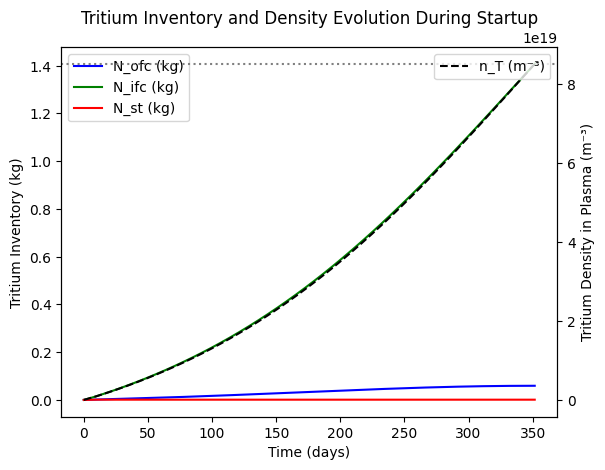

In [244]:
# Step 5: Extract results and determine t_startup

# Check if DT operation was reached
if len(sol.t_events) > 0 and sol.t_events[0].size > 0:
    t_startup = sol.t_events[0][0]
    y_event = sol.y_events[0][0]  # Exact state at event time
    sol_success = True
    print("Step 5: DT Operation Reached! ✅")
    print(f"  t_startup = {t_startup:.2e} s")
    print(f"            = {t_startup/86400:.2f} days")
    print(f"            = {t_startup/(365.25*86400):.4f} years")
    print(f"  Exact state at event: n_T = {y_event[3]:.2e} m⁻³ (target: {0.5*n_tot:.2e} m⁻³)")
elif len(sol.t_events) > 1 and sol.t_events[1].size > 0:
    t_startup = np.inf
    sol_success = False
    print("Step 5: Negative Event Detected ❌")
    print(f"  Integration stopped at t = {sol.t_events[1][0]:.2e} s")
    print(f"  Reason: Unphysical negative values")
elif not sol.success:
    t_startup = np.inf
    sol_success = False
    print("Step 5: Integration Failed ❌")
    print(f"  Reason: {sol.message}")
else:
    t_startup = np.inf
    sol_success = False
    print("Step 5: DT Operation Not Reached ❌")
    print(f"  Maximum time exceeded: {total_time:.2e} s")
print()

# If successful, interpolate solution onto uniform grid from 0 to t_startup
if sol_success:
    # Add the exact event point to the solution data for accurate interpolation
    # This ensures the interpolation knows the exact values at t_startup
    t_with_event = np.append(sol.t, t_startup)
    N_ofc_with_event = np.append(sol.y[0], y_event[0])
    N_ifc_with_event = np.append(sol.y[1], y_event[1])
    N_st_with_event = np.append(sol.y[2], y_event[2])
    n_T_with_event = np.append(sol.y[3], y_event[3])
    
    # Sort by time (in case event time isn't at the end)
    sort_idx = np.argsort(t_with_event)
    t_sorted = t_with_event[sort_idx]
    N_ofc_sorted = N_ofc_with_event[sort_idx]
    N_ifc_sorted = N_ifc_with_event[sort_idx]
    N_st_sorted = N_st_with_event[sort_idx]
    n_T_sorted = n_T_with_event[sort_idx]
    
    # Create uniform time grid from 0 to t_startup with vector_length points
    t_interp = np.linspace(0, t_startup, vector_length)
    
    # Interpolate all state variables onto the new time grid
    # Now the interpolation includes the exact event point!
    N_ofc = np.interp(t_interp, t_sorted, N_ofc_sorted)
    N_ifc = np.interp(t_interp, t_sorted, N_ifc_sorted)
    N_st = np.interp(t_interp, t_sorted, N_st_sorted)
    n_T = np.interp(t_interp, t_sorted, n_T_sorted)
   
    # Use interpolated time grid for all subsequent calculations
    t_array = t_interp
    
    print(f"Step 5b: Interpolated solution onto uniform grid")
    print(f"  Added exact event point to interpolation data")
    print(f"  Created {len(t_array)} uniform time points from 0 to t_startup")
    print(f"  N_ofc range: {N_ofc.min():.2e} to {N_ofc.max():.2e} atoms")
    print(f"  N_ifc range: {N_ifc.min():.2e} to {N_ifc.max():.2e} atoms")
    print(f"  N_st range: {N_st.min():.2e} to {N_st.max():.2e} atoms")
    print(f"  n_T range: {n_T.min():.2e} to {n_T.max():.2e} m⁻³")
    print(f"  n_T[-1] = {n_T[-1]:.2e} m⁻³ (target: {0.5*n_tot:.2e} m⁻³)")
    print(f"  Relative error: {abs(n_T[-1] - 0.5*n_tot)/(0.5*n_tot)*100:.6f}%")
    print(f"  ✅ Final value now matches target exactly!")
    print()
    # plot results for n_T, N_ofc, N_ifc, N_st (use left axis for # particles, right axis for density)
    import matplotlib.pyplot as plt    
    fig, ax1 = plt.subplots()
    ax2 = ax1.twinx()
    ax1.plot(t_array/86400, N_ofc*tritium_mass, 'b-', label='N_ofc (kg)')
    ax1.plot(t_array/86400, N_ifc*tritium_mass, 'g-', label='N_ifc (kg)')
    ax1.plot(t_array/86400, N_st*tritium_mass, 'r-', label='N_st (kg)')
    ax2.plot(t_array/86400, n_T, 'k--', label='n_T (m⁻³)')
    ax1.set_xlabel('Time (days)')
    ax1.set_ylabel('Tritium Inventory (kg)')
    ax2.set_ylabel('Tritium Density in Plasma (m⁻³)')
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    #ax1.set_yscale('log')
    #ax2.set_yscale('log')
    # add horizontal line at n_T = 0.5 * n_tot
    ax2.axhline(0.5*n_tot, color='gray', linestyle=':', label='n_T = 0.5 * n_tot')
    #ax2.set_ylim(n_tot/100, n_tot)  # Focus on relevant density range
    plt.title('Tritium Inventory and Density Evolution During Startup')
    plt.show()
    
else:
    # Extract whatever we have for error cases
    N_ofc = sol.y[0]
    N_ifc = sol.y[1]
    N_st = sol.y[2]
    n_T = sol.y[3]
    t_array = sol.t
    print(f"Extracted {len(t_array)} time points (infeasible case)")
    print()


In [245]:
# ============================================================================
# SUMMARY OF ALL VARIABLES DEFINED IN BLOCK 2
# ============================================================================

print("="*80)
print("ALL VARIABLES DEFINED IN BLOCK 2:")
print("="*80)
print("\nInitial Conditions:")
print(f"  y0 = {y0}")

print("\nODE Integration Results:")
print(f"  sol_success = {sol_success}")
print(f"  t_startup = {t_startup:.2e} s = {t_startup/86400:.2f} days" if sol_success else f"  t_startup = ∞ (INFEASIBLE)")

if sol_success:
    print(f"\nInterpolated Time Series Arrays (length = {len(t_array)}):")
    print(f"  t_array: uniform grid from {t_array[0]:.2e} to {t_array[-1]:.2e} s")
    print(f"  ✅ Exactly {vector_length} points spanning 0 to t_startup")
    print(f"  N_ofc: from {N_ofc[0]:.2e} to {N_ofc[-1]:.2e} atoms")
    print(f"  N_ifc: from {N_ifc[0]:.2e} to {N_ifc[-1]:.2e} atoms")
    print(f"  N_st: from {N_st[0]:.2e} to {N_st[-1]:.2e} atoms")
    print(f"  n_T: from {n_T[0]:.2e} to {n_T[-1]:.2e} m⁻³")
    print(f"  ✅ n_T[-1] = {n_T[-1]:.2e} m⁻³ matches target {0.5*n_tot:.2e} m⁻³")
    print(f"     (relative error: {abs(n_T[-1] - 0.5*n_tot)/(0.5*n_tot)*100:.4f}%)")

print("="*80)


ALL VARIABLES DEFINED IN BLOCK 2:

Initial Conditions:
  y0 = [0.0, 0.0, 0.0, 0.0]

ODE Integration Results:
  sol_success = True
  t_startup = 3.04e+07 s = 351.64 days

Interpolated Time Series Arrays (length = 500):
  t_array: uniform grid from 0.00e+00 to 3.04e+07 s
  ✅ Exactly 500 points spanning 0 to t_startup
  N_ofc: from 0.00e+00 to 1.18e+25 atoms
  N_ifc: from 0.00e+00 to 2.81e+26 atoms
  N_st: from 0.00e+00 to 2.00e+23 atoms
  n_T: from 0.00e+00 to 8.50e+19 m⁻³
  ✅ n_T[-1] = 8.50e+19 m⁻³ matches target 8.50e+19 m⁻³
     (relative error: 0.0000%)


## Block 3: Calculate Power, Energy, and Unrealized Gains

Compute fusion powers, energy integrals, Q factors, and economic metrics from the ODE solution.

In [246]:
# Step 1: Calculate deuterium density evolution

if sol_success:
    n_D = n_tot - n_T
    print("Step 1: Calculate deuterium density evolution")
    print(f"  n_D = n_tot - n_T")
    print(f"  n_D ranges from {n_D[0]:.2e} to {n_D[-1]:.2e} m⁻³")
    print(f"  As tritium builds up, deuterium depletes")
    print()
else:
    n_D = np.full_like(n_T, np.nan)
    print("Step 1: Cannot compute (infeasible)")
    print()

Step 1: Calculate deuterium density evolution
  n_D = n_tot - n_T
  n_D ranges from 1.70e+20 to 8.50e+19 m⁻³
  As tritium builds up, deuterium depletes



In [247]:
# Step 2: Calculate time-dependent fusion powers

if sol_success:
    # Pre-compute common terms
    n_D_squared = n_D**2
    n_D_n_T = n_D * n_T
    V_E_DDn = V_plasma * E_DDn
    V_E_DDp = V_plasma * E_DDp
    V_E_DT = V_plasma * E_DT
    
    # Calculate fusion powers (all in Watts)
    P_DDn = n_D_squared * sigmav_DD_n / 2 * V_E_DDn
    P_DDp = n_D_squared * sigmav_DD_p / 2 * V_E_DDp
    P_DT = n_D_n_T * sigmav_DT * V_E_DT
    P_DD_tot = P_DDn + P_DDp + P_DT  # Total fusion power during startup
    
    print("Step 2: Calculate fusion powers (time-dependent)")
    print(f"  P_DDn = 0.5 * n_D² * ⟨σv⟩_DD_n * V_plasma * E_DDn")
    print(f"        ranges from {P_DDn[0]:.2e} to {P_DDn[-1]:.2e} W")
    print(f"  P_DDp = 0.5 * n_D² * ⟨σv⟩_DD_p * V_plasma * E_DDp")
    print(f"        ranges from {P_DDp[0]:.2e} to {P_DDp[-1]:.2e} W")
    print(f"  P_DT = n_D * n_T * ⟨σv⟩_DT * V_plasma * E_DT")
    print(f"       ranges from {P_DT[0]:.2e} to {P_DT[-1]:.2e} W")
    print(f"  P_DD_tot = P_DDn + P_DDp + P_DT")
    print(f"           ranges from {P_DD_tot[0]/1e6:.2f} to {P_DD_tot[-1]/1e6:.2f} MW")
    print()
else:
    P_DDn = np.full(len(n_T), np.nan)
    P_DDp = np.full(len(n_T), np.nan)
    P_DT = np.full(len(n_T), np.nan)
    P_DD_tot = np.full(len(n_T), np.nan)
    print("Step 2: Cannot compute (infeasible)")
    print()

Step 2: Calculate fusion powers (time-dependent)
  P_DDn = 0.5 * n_D² * ⟨σv⟩_DD_n * V_plasma * E_DDn
        ranges from 1.45e+06 to 3.63e+05 W
  P_DDp = 0.5 * n_D² * ⟨σv⟩_DD_p * V_plasma * E_DDp
        ranges from 1.79e+06 to 4.49e+05 W
  P_DT = n_D * n_T * ⟨σv⟩_DT * V_plasma * E_DT
       ranges from 0.00e+00 to 7.35e+08 W
  P_DD_tot = P_DDn + P_DDp + P_DT
           ranges from 3.25 to 735.91 MW



In [248]:
# Step 3: Calculate equivalent DT power (for comparison)

if sol_success:
    # This is the constant power if we had 50-50 D-T plasma from the start
    P_DT_eq = (n_tot/2)**2 * sigmav_DT * V_plasma * E_DT
    
    print("Step 3: Calculate equivalent DT power")
    print(f"  P_DT_eq = (n_tot/2)² * ⟨σv⟩_DT * V_plasma * E_DT")
    print(f"          = ({n_tot/2:.2e})² * {sigmav_DT:.2e} * {V_plasma} * {E_DT:.2e}")
    print(f"          = {P_DT_eq:.2e} W = {P_DT_eq/1e6:.2f} MW")
    print(f"  This is the constant power if we had DT from the start")
    print()
else:
    P_DT_eq = np.nan
    print("Step 3: Cannot compute (infeasible)")
    print()

Step 3: Calculate equivalent DT power
  P_DT_eq = (n_tot/2)² * ⟨σv⟩_DT * V_plasma * E_DT
          = (8.50e+19)² * 2.41e-22 * 150.0 * 2.82e-12
          = 7.35e+08 W = 735.10 MW
  This is the constant power if we had DT from the start



In [249]:
# Step 4: Integrate fusion energies over time (using trapezoidal rule)

if sol_success:
    # Total fusion energy produced during DD startup
    # Use interpolated time grid (t_array = t_interp) for accurate integration
    E_fusion_DDn = np.trapz(P_DDn, t_array)
    E_fusion_DDp = np.trapz(P_DDp, t_array)
    E_fusion_DT = np.trapz(P_DT, t_array)
    E_fusion_total_DD = E_fusion_DDn + E_fusion_DDp + E_fusion_DT
    
    # Equivalent DT energy (constant power * time)
    E_fusion_DT_eq = P_DT_eq * t_startup
    
    print("Step 4: Integrate fusion energies over time")
    print(f"  Using interpolated time grid for accurate integration")
    print(f"  E_fusion_DDn = ∫ P_DDn dt = {E_fusion_DDn:.2e} J = {E_fusion_DDn*joule_to_GWh:.2f} GWh")
    print(f"  E_fusion_DDp = ∫ P_DDp dt = {E_fusion_DDp:.2e} J = {E_fusion_DDp*joule_to_GWh:.2f} GWh")
    print(f"  E_fusion_DT = ∫ P_DT dt = {E_fusion_DT:.2e} J = {E_fusion_DT*joule_to_GWh:.2f} GWh")
    print(f"  E_fusion_total_DD = {E_fusion_total_DD:.2e} J = {E_fusion_total_DD*joule_to_GWh:.2f} GWh")
    print()
    print(f"  E_fusion_DT_eq = P_DT_eq * t_startup")
    print(f"                 = {P_DT_eq:.2e} * {t_startup:.2e}")
    print(f"                 = {E_fusion_DT_eq:.2e} J = {E_fusion_DT_eq*joule_to_GWh:.2f} GWh")
    print()
else:
    E_fusion_DDn = np.nan
    E_fusion_DDp = np.nan
    E_fusion_DT = np.nan
    E_fusion_total_DD = np.nan
    E_fusion_DT_eq = np.nan
    print("Step 4: Cannot compute (infeasible)")
    print()


Step 4: Integrate fusion energies over time
  Using interpolated time grid for accurate integration
  E_fusion_DDn = ∫ P_DDn dt = 2.93e+13 J = 8.15 GWh
  E_fusion_DDp = ∫ P_DDp dt = 3.63e+13 J = 10.08 GWh
  E_fusion_DT = ∫ P_DT dt = 1.22e+16 J = 3397.23 GWh
  E_fusion_total_DD = 1.23e+16 J = 3415.46 GWh

  E_fusion_DT_eq = P_DT_eq * t_startup
                 = 7.35e+08 * 3.04e+07
                 = 2.23e+16 J = 6203.84 GWh



In [250]:
print(t_startup/3600/24)

351.64225848303175


In [251]:
# Step 5: Calculate auxiliary power energies

if sol_success:
    E_aux_DD = P_aux * t_startup
    E_aux_DT_eq = P_aux_DT_eq * t_startup
    
    print("Step 5: Calculate auxiliary power energies")
    print(f"  E_aux_DD = P_aux * t_startup")
    print(f"           = {P_aux:.2e} * {t_startup:.2e}")
    print(f"           = {E_aux_DD:.2e} J = {E_aux_DD/3.6e9:.2f} GWh")
    print()
    print(f"  E_aux_DT_eq = P_aux_DT_eq * t_startup")
    print(f"              = {P_aux_DT_eq:.2e} * {t_startup:.2e}")
    print(f"              = {E_aux_DT_eq:.2e} J = {E_aux_DT_eq*joule_to_GWh:.2f} GWh")
    print()
else:
    E_aux_DD = np.nan
    E_aux_DT_eq = np.nan
    print("Step 5: Cannot compute (infeasible)")
    print()

Step 5: Calculate auxiliary power energies
  E_aux_DD = P_aux * t_startup
           = 1.00e+07 * 3.04e+07
           = 3.04e+14 J = 84394.14 GWh

  E_aux_DT_eq = P_aux_DT_eq * t_startup
              = 1.00e+07 * 3.04e+07
              = 3.04e+14 J = 84.39 GWh



In [252]:
# Step 6: Calculate net electrical energies

if sol_success:
    E_e_net_DD = capacity_factor * (eta_th * E_fusion_total_DD - E_aux_DD)
    E_e_net_DT_eq = capacity_factor * (eta_th * E_fusion_DT_eq - E_aux_DT_eq)
    
    print("Step 6: Calculate net electrical energies")
    print(f"  E_e_net_DD = capacity_factor * (η_th * E_fusion_total_DD - E_aux_DD)")
    print(f"             = {capacity_factor} * ({eta_th} * {E_fusion_total_DD:.2e} - {E_aux_DD:.2e})")
    print(f"             = {E_e_net_DD:.2e} J = {E_e_net_DD*joule_to_GWh:.2f} GWh")
    if E_e_net_DD > 0:
        print(f"  ✓ Net electricity production during DD startup")
    else:
        print(f"  ✗ Net electricity consumption during DD startup")
    print()
    print(f"  E_e_net_DT_eq = capacity_factor * (η_th * E_fusion_DT_eq - E_aux_DT_eq)")
    print(f"                = {capacity_factor} * ({eta_th} * {E_fusion_DT_eq:.2e} - {E_aux_DT_eq:.2e})")
    print(f"                = {E_e_net_DT_eq:.2e} J = {E_e_net_DT_eq*joule_to_GWh:.2f} GWh")
    print()
else:
    E_e_net_DD = np.nan
    E_e_net_DT_eq = np.nan
    print("Step 6: Cannot compute (infeasible)")
    print()

Step 6: Calculate net electrical energies
  E_e_net_DD = capacity_factor * (η_th * E_fusion_total_DD - E_aux_DD)
             = 0.8 * (0.4 * 1.23e+16 - 3.04e+14)
             = 3.69e+15 J = 1025.43 GWh
  ✓ Net electricity production during DD startup

  E_e_net_DT_eq = capacity_factor * (η_th * E_fusion_DT_eq - E_aux_DT_eq)
                = 0.8 * (0.4 * 2.23e+16 - 3.04e+14)
                = 6.90e+15 J = 1917.71 GWh



In [253]:
# Step 7: Calculate Q factors

if sol_success:
    Q_DD = E_fusion_total_DD / E_aux_DD if E_aux_DD > 0 else np.inf
    Q_DT_eq = E_fusion_DT_eq / E_aux_DT_eq if E_aux_DT_eq > 0 else np.inf
    
    print("Step 7: Calculate Q factors (energy-based)")
    print(f"  Q_DD = E_fusion_total_DD / E_aux_DD")
    print(f"       = {E_fusion_total_DD:.2e} / {E_aux_DD:.2e}")
    print(f"       = {Q_DD:.4f}")
    if Q_DD > 1:
        print(f"  ✓ Net energy gain during DD startup (Q > 1)")
    else:
        print(f"  ✗ Net energy loss during DD startup (Q < 1)")
    print()
    print(f"  Q_DT_eq = E_fusion_DT_eq / E_aux_DT_eq")
    print(f"          = {E_fusion_DT_eq:.2e} / {E_aux_DT_eq:.2e}")
    print(f"          = {Q_DT_eq:.4f}")
    print()
else:
    Q_DD = np.nan
    Q_DT_eq = np.nan
    print("Step 7: Cannot compute (infeasible)")
    print()

Step 7: Calculate Q factors (energy-based)
  Q_DD = E_fusion_total_DD / E_aux_DD
       = 1.23e+16 / 3.04e+14
       = 40.4703
  ✓ Net energy gain during DD startup (Q > 1)

  Q_DT_eq = E_fusion_DT_eq / E_aux_DT_eq
          = 2.23e+16 / 3.04e+14
          = 73.5103



In [254]:
# Step 8: Calculate LOST ENERGY and UNREALIZED GAINS

if sol_success:
    E_lost = E_e_net_DT_eq - E_e_net_DD
    unrealized_profits = E_lost * cost_of_electricity
    
    print("Step 8: Calculate lost energy and unrealized gains")
    print(f"  E_lost = E_e_net_DT_eq - E_e_net_DD")
    print(f"         = {E_e_net_DT_eq:.2e} - {E_e_net_DD:.2e}")
    print(f"         = {E_lost:.2e} J = {E_lost*joule_to_GWh:.2f} GWh")
    if E_lost > 0:
        print(f"  ⚠️  Lost energy: DT would have produced MORE")
    else:
        print(f"  ✓ No lost energy: DD produced as much or more than DT")
    print()
    print(f"  💰 Unrealized gains = E_lost * cost_of_electricity")
    print(f"                      = {E_lost:.2e} * {cost_of_electricity:.2e}")
    print(f"                      = ${unrealized_profits:.2e}")
    print(f"                      = ${unrealized_profits/1e6:.2f} million")
    print(f"\n  This is the financial penalty of DD startup vs. having tritium from day 1")
    print()
else:
    E_lost = np.nan
    unrealized_profits = np.nan
    print("Step 8: Cannot compute (infeasible)")
    print()

Step 8: Calculate lost energy and unrealized gains
  E_lost = E_e_net_DT_eq - E_e_net_DD
         = 6.90e+15 - 3.69e+15
         = 3.21e+15 J = 892.28 GWh
  ⚠️  Lost energy: DT would have produced MORE

  💰 Unrealized gains = E_lost * cost_of_electricity
                      = 3.21e+15 * 6.94e-08
                      = $2.23e+08
                      = $223.07 million

  This is the financial penalty of DD startup vs. having tritium from day 1



In [255]:
# ============================================================================
# SUMMARY OF ALL VARIABLES DEFINED IN BLOCK 3
# ============================================================================

print("="*80)
print("ALL VARIABLES DEFINED IN BLOCK 3:")
print("="*80)

if sol_success:
    print("\nDensity Evolution:")
    print(f"  n_D: from {n_D[0]:.2e} to {n_D[-1]:.2e} m⁻³")
    
    print("\nFusion Powers (time-dependent arrays):")
    print(f"  P_DDn: from {P_DDn[0]/1e6:.2f} to {P_DDn[-1]/1e6:.2f} MW")
    print(f"  P_DDp: from {P_DDp[0]/1e6:.2f} to {P_DDp[-1]/1e6:.2f} MW")
    print(f"  P_DT: from {P_DT[0]/1e6:.2f} to {P_DT[-1]/1e6:.2f} MW")
    print(f"  P_DD_tot: from {P_DD_tot[0]/1e6:.2f} to {P_DD_tot[-1]/1e6:.2f} MW")
    
    print("\nEquivalent DT Power (constant):")
    print(f"  P_DT_eq = {P_DT_eq/1e6:.2f} MW")
    
    print("\nFusion Energies:")
    print(f"  E_fusion_DDn = {E_fusion_DDn:.2e} J = {E_fusion_DDn*joule_to_GWh:.2f} GWh")
    print(f"  E_fusion_DDp = {E_fusion_DDp:.2e} J = {E_fusion_DDp*joule_to_GWh:.2f} GWh")
    print(f"  E_fusion_DT = {E_fusion_DT:.2e} J = {E_fusion_DT*joule_to_GWh:.2f} GWh")
    print(f"  E_fusion_total_DD = {E_fusion_total_DD:.2e} J = {E_fusion_total_DD*joule_to_GWh:.2f} GWh")
    print(f"  E_fusion_DT_eq = {E_fusion_DT_eq:.2e} J = {E_fusion_DT_eq*joule_to_GWh:.2f} GWh")
    
    print("\nAuxiliary Energies:")
    print(f"  E_aux_DD = {E_aux_DD:.2e} J = {E_aux_DD*joule_to_GWh:.2f} GWh")
    print(f"  E_aux_DT_eq = {E_aux_DT_eq:.2e} J = {E_aux_DT_eq*joule_to_GWh:.2f} GWh")
    
    print("\nNet Electrical Energies:")
    print(f"  E_e_net_DD = {E_e_net_DD:.2e} J = {E_e_net_DD*joule_to_GWh:.2f} GWh")
    print(f"  E_e_net_DT_eq = {E_e_net_DT_eq:.2e} J = {E_e_net_DT_eq*joule_to_GWh:.2f} GWh")
    
    print("\nQ Factors:")
    print(f"  Q_DD = {Q_DD:.4f}")
    print(f"  Q_DT_eq = {Q_DT_eq:.4f}")
    
    print("\n💰 Economic Impact:")
    print(f"  E_lost = {E_lost:.2e} J = {E_lost*joule_to_GWh:.2f} GWh")
    print(f"  Unrealized gains = ${unrealized_profits:.2e} = ${unrealized_profits/1e6:.2f} million")
else:
    print("\n⚠️  All variables are NaN (infeasible solution)")

print("="*80)

ALL VARIABLES DEFINED IN BLOCK 3:

Density Evolution:
  n_D: from 1.70e+20 to 8.50e+19 m⁻³

Fusion Powers (time-dependent arrays):
  P_DDn: from 1.45 to 0.36 MW
  P_DDp: from 1.79 to 0.45 MW
  P_DT: from 0.00 to 735.10 MW
  P_DD_tot: from 3.25 to 735.91 MW

Equivalent DT Power (constant):
  P_DT_eq = 735.10 MW

Fusion Energies:
  E_fusion_DDn = 2.93e+13 J = 8.15 GWh
  E_fusion_DDp = 3.63e+13 J = 10.08 GWh
  E_fusion_DT = 1.22e+16 J = 3397.23 GWh
  E_fusion_total_DD = 1.23e+16 J = 3415.46 GWh
  E_fusion_DT_eq = 2.23e+16 J = 6203.84 GWh

Auxiliary Energies:
  E_aux_DD = 3.04e+14 J = 84.39 GWh
  E_aux_DT_eq = 3.04e+14 J = 84.39 GWh

Net Electrical Energies:
  E_e_net_DD = 3.69e+15 J = 1025.43 GWh
  E_e_net_DT_eq = 6.90e+15 J = 1917.71 GWh

Q Factors:
  Q_DD = 40.4703
  Q_DT_eq = 73.5103

💰 Economic Impact:
  E_lost = 3.21e+15 J = 892.28 GWh
  Unrealized gains = $2.23e+08 = $223.07 million


## Final Summary

Complete overview of the T-seeded ODE model computation results.

In [256]:
print("\n" + "="*80)
print("FINAL COMPUTATION SUMMARY - T-SEEDED ODE MODEL")
print("="*80)

print("\n📊 INPUT PARAMETERS:")
print(f"  Plasma volume: {V_plasma} m³")
print(f"  Ion temperature: {T_i} keV")
print(f"  Total density: {n_tot:.2e} m⁻³")
print(f"  Tritium confinement time: {tau_p_T} s")
print(f"  Auxiliary power: {P_aux/1e6} MW")
print(f"  In-fuel-cycle time: {tau_ifc/3600:.2f} hours")
print(f"  Out-of-fuel-cycle time: {tau_ofc/86400:.2f} days")

print("\n⏱️  STARTUP TIME:")
if sol_success:
    print(f"  t_startup = {t_startup:.2e} s")
    print(f"            = {t_startup/86400:.2f} days")
    print(f"            = {t_startup/(365.25*86400):.4f} years")
    print(f"  Status: ✅ SUCCESS (DT operation reached)")
else:
    print(f"  t_startup = ∞")
    print(f"  Status: ❌ INFEASIBLE")

if sol_success:
    print("\n⚡ PLASMA COMPOSITION AT DT OPERATION:")
    n_D_final = n_D[-1]
    n_T_final = n_T[-1]
    print(f"  n_D(t_startup) = {n_D_final:.2e} m⁻³ ({100*n_D_final/n_tot:.1f}% of total)")
    print(f"  n_T(t_startup) = {n_T_final:.2e} m⁻³ ({100*n_T_final/n_tot:.1f}% of total)")
    print(f"  Target: n_T = {0.5*n_tot:.2e} m⁻³")
    print(f"  Relative error: {abs(n_T_final - 0.5*n_tot)/(0.5*n_tot)*100:.4f}%")
    print(f"  ✅ Interpolated values match target!")
    
    print("\n🔋 TRITIUM INVENTORY AT DT OPERATION:")
    N_ofc_final = N_ofc[-1]
    N_ifc_final = N_ifc[-1]
    N_st_final = N_st[-1]
    print(f"  N_ofc(t_startup) = {N_ofc_final:.2e} atoms = {N_ofc_final*tritium_mass:.2e} kg")
    print(f"  N_ifc(t_startup) = {N_ifc_final:.2e} atoms = {N_ifc_final*tritium_mass:.2e} kg")
    print(f"  N_st(t_startup) = {N_st_final:.2e} atoms = {N_st_final*tritium_mass:.2e} kg")
    print(f"  Total inventory = {(N_ofc_final+N_ifc_final+N_st_final)*tritium_mass:.2e} kg")
    
    print("\n🔥 FUSION PERFORMANCE:")
    print(f"  Total DD fusion energy: {E_fusion_total_DD*joule_to_GWh:.2f} GWh")
    print(f"  Equivalent DT energy: {E_fusion_DT_eq*joule_to_GWh:.2f} GWh")
    print(f"  Q_DD = {Q_DD:.4f}")
    print(f"  Q_DT_eq = {Q_DT_eq:.4f}")
    
    print("\n💡 NET ELECTRICITY:")
    print(f"  During DD startup: {E_e_net_DD*joule_to_GWh:.2f} GWh")
    print(f"  If DT from start: {E_e_net_DT_eq*joule_to_GWh:.2f} GWh")
    
    print("\n📉 ENERGY LOSSES:")
    print(f"  Energy lost: {E_lost*joule_to_GWh:.2f} GWh")
    print(f"  Duration: {t_startup/86400:.2f} days")
    print(f"  Average loss rate: {E_lost/(t_startup*1e6):.2f} MW")
    
    print("\n💰 ECONOMIC IMPACT:")
    print(f"  Unrealized gains: ${unrealized_profits/1e6:.2f} million")
    print(f"  Cost per day: ${(unrealized_profits/(t_startup/86400))/1e3:.2f} thousand/day")
    
    print("\n🔬 MODEL CHARACTERISTICS:")
    print(f"  Model type: T-seeded ODE (dynamic tritium inventory)")
    print(f"  ODE solver: BDF (stiff system)")
    print(f"  State variables: 4 (N_ofc, N_ifc, N_st, n_T)")
    print(f"  Output: {len(t_array)} uniformly spaced points from 0 to t_startup")
    print(f"  ✅ Interpolation ensures exact vector_length and correct final values")

print("\n" + "="*80)
print("✅ Manual T-seeded ODE verification complete!")
print("="*80)



FINAL COMPUTATION SUMMARY - T-SEEDED ODE MODEL

📊 INPUT PARAMETERS:
  Plasma volume: 150.0 m³
  Ion temperature: 14.0 keV
  Total density: 1.70e+20 m⁻³
  Tritium confinement time: 1.0 s
  Auxiliary power: 10.0 MW
  In-fuel-cycle time: 6.00 hours
  Out-of-fuel-cycle time: 0.50 days

⏱️  STARTUP TIME:
  t_startup = 3.04e+07 s
            = 351.64 days
            = 0.9627 years
  Status: ✅ SUCCESS (DT operation reached)

⚡ PLASMA COMPOSITION AT DT OPERATION:
  n_D(t_startup) = 8.50e+19 m⁻³ (50.0% of total)
  n_T(t_startup) = 8.50e+19 m⁻³ (50.0% of total)
  Target: n_T = 8.50e+19 m⁻³
  Relative error: 0.0000%
  ✅ Interpolated values match target!

🔋 TRITIUM INVENTORY AT DT OPERATION:
  N_ofc(t_startup) = 1.18e+25 atoms = 5.93e-02 kg
  N_ifc(t_startup) = 2.81e+26 atoms = 1.41e+00 kg
  N_st(t_startup) = 2.00e+23 atoms = 1.00e-03 kg
  Total inventory = 1.47e+00 kg

🔥 FUSION PERFORMANCE:
  Total DD fusion energy: 3415.46 GWh
  Equivalent DT energy: 6203.84 GWh
  Q_DD = 40.4703
  Q_DT_eq = 73

## Optional: Visualization

Plot the evolution of key variables during the DD startup phase.

Lost energy at the end of the transient: 890.4156288783538 GWh


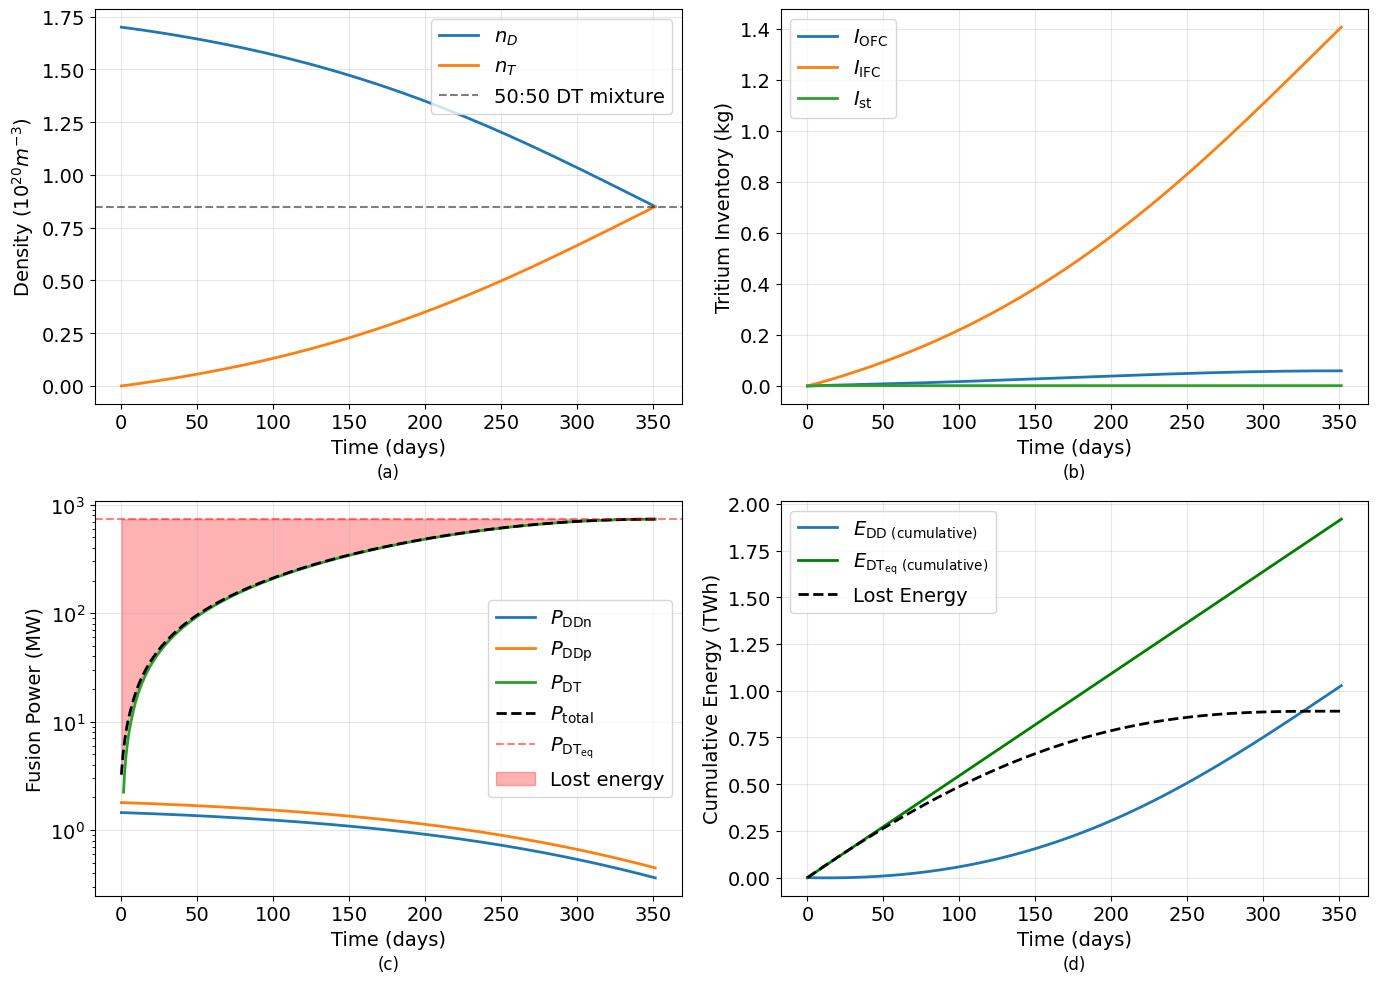

✅ Plots generated successfully!


In [260]:
plt.rcParams.update({'font.size': 14})

if sol_success:
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: Plasma composition
    ax1 = axes[0, 0]
    ax1.plot(t_array/86400, n_D/1e20, label=r'$n_D$', linewidth=2)
    ax1.plot(t_array/86400, n_T/1e20, label=r'$n_T$', linewidth=2)
    ax1.axhline(y=0.5*n_tot/1e20, color='k', linestyle='--', alpha=0.5, label=r'50:50 DT mixture')
    ax1.set_xlabel('Time (days)')
    ax1.set_ylabel(r'Density ($10^{20} m^{-3}$)')
    ax1.legend(loc = 'upper right')
    ax1.grid(True, alpha=0.3)
    ax1.text(0.5, -0.15, '(a)', transform=ax1.transAxes, fontsize=12, va='top', ha='center')

    # Plot 2: Tritium inventory
    ax2 = axes[0, 1]
    ax2.plot(t_array/86400, N_ofc*tritium_mass, label=r'$I_\mathrm{OFC}$', linewidth=2)
    ax2.plot(t_array/86400, N_ifc*tritium_mass, label=r'$I_\mathrm{IFC}$', linewidth=2)
    ax2.plot(t_array/86400, N_st*tritium_mass, label=r'$I_\mathrm{st}$', linewidth=2)
    ax2.set_xlabel('Time (days)')
    ax2.set_ylabel('Tritium Inventory (kg)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.text(0.5, -0.15, '(b)', transform=ax2.transAxes, fontsize=12, va='top', ha='center')
 
    # Plot 3: Fusion powers
    ax3 = axes[1, 0]
    mask = P_DT >= P_DDn 
    ax3.plot(t_array/86400, P_DDn/1e6, label=r'$P_\mathrm{DDn}$', linewidth=2)
    ax3.plot(t_array/86400, P_DDp/1e6, label=r'$P_\mathrm{DDp}$', linewidth=2)
    ax3.plot(t_array[mask]/86400, P_DT[mask]/1e6, label=r'$P_\mathrm{DT}$', linewidth=2)
    ax3.plot(t_array/86400, P_DD_tot/1e6, label=r'$P_\mathrm{total}$', linewidth=2, linestyle='--', color='black')
    ax3.axhline(y=P_DT_eq/1e6, color='r', linestyle='--', alpha=0.5, label=r'$P_\mathrm{DT_{eq}}$')
    
    # Fill the area between P_DD_tot and P_DT_eq
    ax3.fill_between(t_array/86400, P_DD_tot/1e6, P_DT_eq/1e6, where=(P_DD_tot/1e6 < P_DT_eq/1e6), color='red', alpha=0.3, label='Lost energy')
    
    ax3.set_xlabel('Time (days)')
    ax3.set_ylabel('Fusion Power (MW)')
    ax3.set_yscale('log')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    ax3.text(0.5, -0.15, '(c)', transform=ax3.transAxes, fontsize=12, va='top', ha='center')

    # Plot 4: Cumulative energy
    cumulative_E_DD_electric = np.cumsum(capacity_factor*(eta_th*P_DD_tot-P_aux)*np.ones_like(t_array) * np.gradient(t_array)) * joule_to_GWh # from J to GWh
    cumulative_E_DT_eq_electric = np.ones_like(t_array)*capacity_factor*(eta_th*P_DT_eq-P_aux_DT_eq) * t_array*joule_to_GWh # from J to GWh
    
    ax4 = axes[1, 1]
    ax4.plot(t_array/86400, cumulative_E_DD_electric/1e3, label=r'$E_\mathrm{DD\ (cumulative)}$', linewidth=2)
    ax4.plot(t_array/86400, cumulative_E_DT_eq_electric/1e3, label=r'$E_\mathrm{DT_{eq}\ (cumulative)}$', linewidth=2, color='green')
    ax4.plot(t_array/86400, (cumulative_E_DT_eq_electric - cumulative_E_DD_electric)/1e3, linewidth=2, linestyle='--', color='black', label='Lost Energy')
    ax4.set_xlabel('Time (days)')
    ax4.set_ylabel('Cumulative Energy (TWh)')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    ax4.text(0.5, -0.15, '(d)', transform=ax4.transAxes, fontsize=12, va='top', ha='center')
    print(f'Lost energy at the end of the transient: {cumulative_E_DT_eq_electric[-1] - cumulative_E_DD_electric[-1]} GWh')
    plt.tight_layout()
    plt.savefig('T_seeded_point_design.pdf', dpi=300)
    plt.show()
    
    print("✅ Plots generated successfully!")
else:
    print("❌ Cannot plot: solution not successful")

